# Lane Detection — Sliding Windows

Unified port of `LaneDetection_v2.py` (lane overlay) and `autonomousVehicle.py`
(curvature / offset / steering), run stage by stage on a single frame.

Differences from the scripts, all forced by the notebook:
- No `cv2.imshow` / trackbar windows — frames render with matplotlib, and the HSV
  bounds the trackbars supplied are constants below (their script defaults).
- One point per sliding window (largest contour) instead of one per contour, so the
  detected x-positions line up with their source rows for the polynomial fit.
- Window slices are clamped to the frame, which the scripts do not do.

In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline


def show(img, title="", size=(8, 5)):
    """Render a BGR or single-channel image inline."""
    plt.figure(figsize=size)
    if img.ndim == 3:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    else:
        plt.imshow(img, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()

## Constants

Every value below is calibrated to `LaneVideo.mp4` at 640x480. A different video —
or a different camera mounting — needs new `SRC` points and probably new HSV bounds.

In [17]:
VIDEO = "LaneVideo.mp4"
FRAME_W, FRAME_H = 640, 480

# Perspective source points (top-left, bottom-left, top-right, bottom-right)
SRC = np.float32([(222, 387), (70, 472), (400, 380), (538, 472)])
DST = np.float32([[0, 0], [0, FRAME_H], [FRAME_W, 0], [FRAME_W, FRAME_H]])

# HSV bounds: bright, low-saturation pixels — i.e. white lane paint.
# These are the trackbar defaults; tune them here.
HSV_LOWER = np.array([0, 0, 200])
HSV_UPPER = np.array([255, 50, 255])

# Sliding window geometry
Y_START = 472       # bottom row to start from, per the original scripts
WIN_H = 40          # window height in px
WIN_MARGIN = 50     # half-width of each window
N_WINDOWS = 12

CAR_X = FRAME_W // 2    # camera assumed centred on the car
XM_PER_PIX = 3.7 / FRAME_W  # US lane width (3.7 m) spans the warped frame

## Step 1 — Read a frame

Every stage below runs on this one frame; the last section replays the whole video.

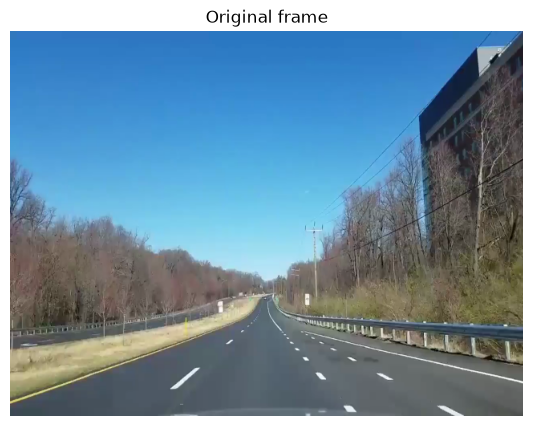

In [18]:
cap = cv2.VideoCapture(VIDEO)
ok, image = cap.read()
cap.release()
assert ok, f"could not read {VIDEO} — run this notebook from the repo root"

frame = cv2.resize(image, (FRAME_W, FRAME_H))
show(frame, "Original frame")

## Step 2 — Region of interest

The four points that bound the road surface, drawn to confirm they still fit the lane.

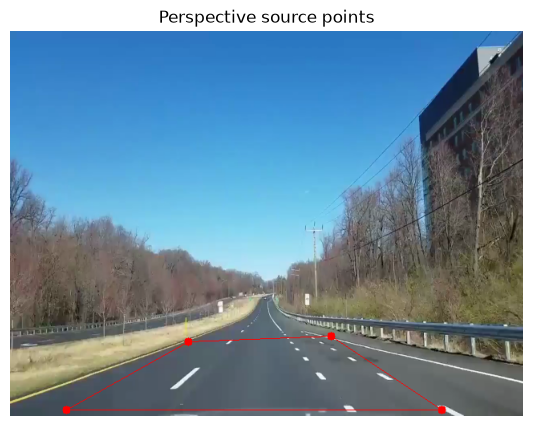

In [19]:
roi_preview = frame.copy()
for x, y in SRC.astype(int):
    cv2.circle(roi_preview, (x, y), 5, (0, 0, 255), -1)
cv2.polylines(roi_preview, [SRC.astype(np.int32)[[0, 1, 3, 2]]], True, (0, 0, 255), 1)

show(roi_preview, "Perspective source points")

## Step 3 — Perspective transform

Warping those four points onto the full frame gives a bird's-eye view, where lane
lines are near-vertical and their curvature is measurable.

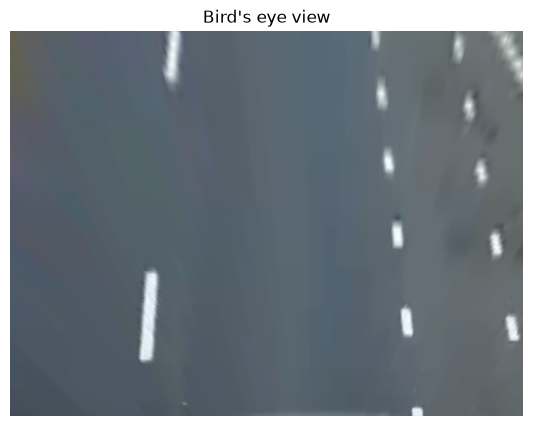

In [20]:
M = cv2.getPerspectiveTransform(SRC, DST)
M_INV = cv2.getPerspectiveTransform(DST, SRC)


def birdseye(img):
    return cv2.warpPerspective(img, M, (FRAME_W, FRAME_H))


warped = birdseye(frame)
show(warped, "Bird's eye view")

## Step 4 — Threshold

HSV isolates the paint far more cleanly than BGR: lane markings are bright (high V)
and nearly colourless (low S), whatever the road surface underneath.

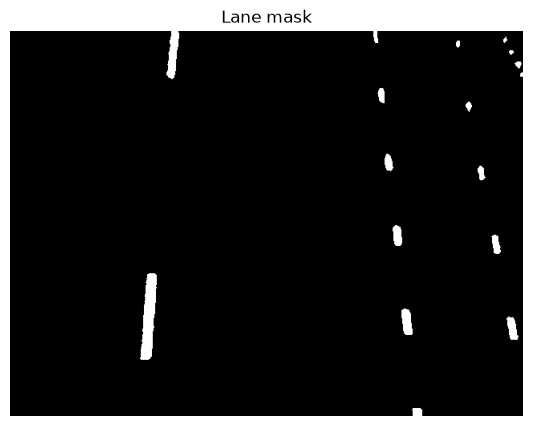

In [21]:
def threshold_lanes(warped_img):
    hsv = cv2.cvtColor(warped_img, cv2.COLOR_BGR2HSV)
    return cv2.inRange(hsv, HSV_LOWER, HSV_UPPER)


mask = threshold_lanes(warped)
show(mask, "Lane mask")

## Step 5 — Histogram

Column sums over the bottom half of the mask. The two peaks, one either side of the
midpoint, are where the lanes meet the bottom of the frame — the starting x for the
sliding windows.

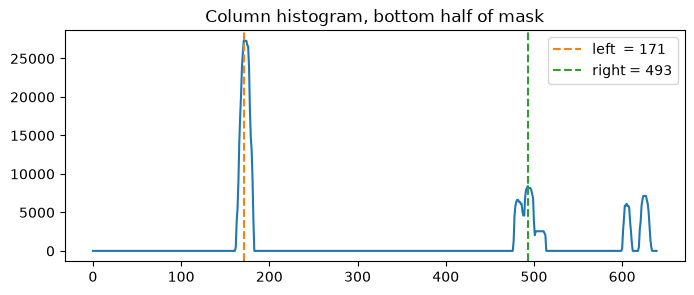

In [22]:
def lane_bases(mask):
    histogram = mask[mask.shape[0] // 2:, :].sum(axis=0)
    midpoint = histogram.shape[0] // 2
    left = int(np.argmax(histogram[:midpoint]))
    right = int(np.argmax(histogram[midpoint:])) + midpoint
    return left, right, histogram


left_base, right_base, histogram = lane_bases(mask)

plt.figure(figsize=(8, 3))
plt.plot(histogram)
plt.axvline(left_base, color="tab:orange", ls="--", label=f"left  = {left_base}")
plt.axvline(right_base, color="tab:green", ls="--", label=f"right = {right_base}")
plt.title("Column histogram, bottom half of mask")
plt.legend()
plt.show()

## Step 6 — Sliding windows

Walk up from the bottom in `WIN_H` steps. Each window takes the centroid of its
largest contour and recentres the next window on it, so the search follows the lane
as it curves.

The scripts append a point per contour, which silently desynchronises the x-positions
from their rows; taking only the largest keeps one point per window.

left points: 6   right points: 7


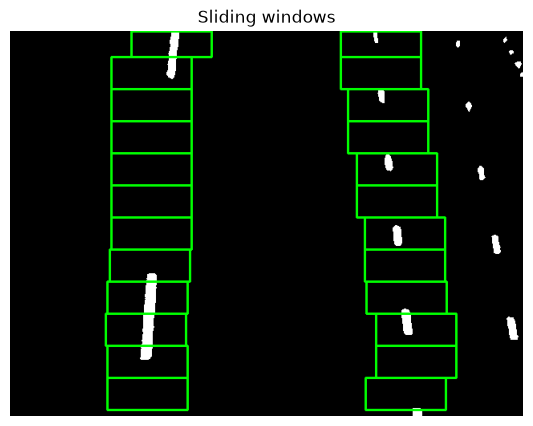

In [23]:
def sliding_windows(mask, left_base, right_base, debug_img=None):
    """Track both lanes upward. Returns (lx, ly), (rx, ry) in warped pixels."""
    h, w = mask.shape
    bases = {"left": left_base, "right": right_base}
    points = {"left": ([], []), "right": ([], [])}

    y = Y_START
    for _ in range(N_WINDOWS):
        y0, y1 = max(0, y - WIN_H), y
        if y0 >= y1:
            break
        for side in ("left", "right"):
            base = bases[side]
            x0, x1 = max(0, base - WIN_MARGIN), min(w, base + WIN_MARGIN)
            contours, _ = cv2.findContours(
                mask[y0:y1, x0:x1], cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
            )
            if contours:
                m = cv2.moments(max(contours, key=cv2.contourArea))
                if m["m00"] != 0:
                    bases[side] = x0 + int(m["m10"] / m["m00"])
                    points[side][0].append(bases[side])
                    points[side][1].append((y0 + y1) // 2)  # window centre row
            if debug_img is not None:
                cv2.rectangle(debug_img, (x0, y1), (x1, y0), (0, 255, 0), 2)
        y -= WIN_H

    return points["left"], points["right"]


windows_img = cv2.cvtColor(mask, cv2.COLOR_GRAY2BGR)
(lx, ly), (rx, ry) = sliding_windows(mask, left_base, right_base, windows_img)

print(f"left points: {len(lx)}   right points: {len(rx)}")
show(windows_img, "Sliding windows")

## Step 7 — Lane overlay

Fill the polygon between the tracked points, then warp it back through the inverse
matrix so it lands on the original camera view.

The scripts use only the first and last point of each lane, which draws a straight
quadrilateral; using every point follows the curve.

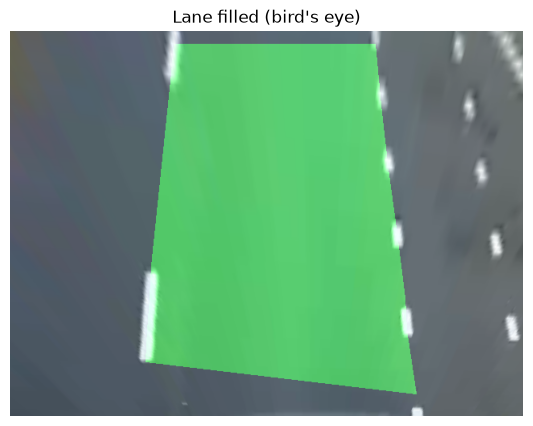

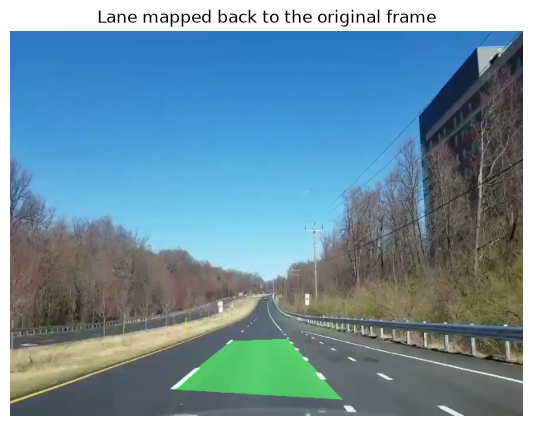

In [24]:
def draw_lane(frame, warped, lx, ly, rx, ry, alpha=0.4):
    """Fill the lane in warped space and unwarp it onto the original frame."""
    if len(lx) < 2 or len(rx) < 2:
        return frame.copy(), warped.copy()

    left = np.column_stack([lx, ly])
    right = np.column_stack([rx, ry])[::-1]  # reversed, to close the polygon
    poly = np.vstack([left, right]).astype(np.int32)

    # Fill on a black canvas, not on the frame: unwarping a copy of the road and
    # adding it back would brighten the whole trapezoid, not just the lane.
    green = np.zeros_like(warped)
    cv2.fillPoly(green, [poly], (0, 255, 0))

    birdseye_view = cv2.addWeighted(warped, 1, green, alpha, 0)
    unwarped = cv2.warpPerspective(green, M_INV, (FRAME_W, FRAME_H))
    return cv2.addWeighted(frame, 1, unwarped, alpha, 0), birdseye_view


result, warped_overlay = draw_lane(frame, warped, lx, ly, rx, ry)
show(warped_overlay, "Lane filled (bird's eye)")
show(result, "Lane mapped back to the original frame")

## Step 8 — Curvature, offset, steering

Fit `x = ay^2 + by + c` to each lane, then read off the standard radius-of-curvature
formula at the bottom of the frame.

Curvature stays in **pixels**: converting it to metres needs a vertical scale
(metres per pixel *after* the warp) that this footage isn't calibrated for. The
lateral offset does convert, since a lane's 3.7 m width spans the warped frame.

(np.float64(12461.565461348013), np.float64(-0.101657350274855), np.float64(-0.0004674001147904739))


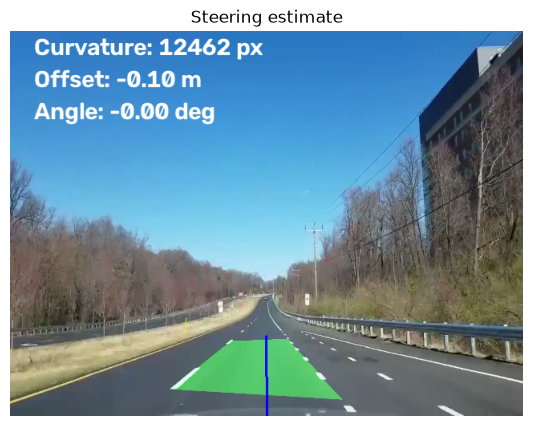

In [25]:
def lane_metrics(lx, ly, rx, ry):
    """Returns (curvature_px, offset_m, steering_deg), or None if underdetermined."""
    if len(lx) < 3 or len(rx) < 3:
        return None

    left_fit = np.polyfit(ly, lx, 2)
    right_fit = np.polyfit(ry, rx, 2)

    y_eval = FRAME_H
    def radius(fit):
        # ponytail: pixel-space radius; add a y metres-per-pixel scale once calibrated
        return (1 + (2 * fit[0] * y_eval + fit[1]) ** 2) ** 1.5 / max(abs(2 * fit[0]), 1e-6)

    curvature = (radius(left_fit) + radius(right_fit)) / 2
    lane_center = (np.polyval(left_fit, y_eval) + np.polyval(right_fit, y_eval)) / 2
    offset = (CAR_X - lane_center) * XM_PER_PIX
    steering = np.degrees(np.arctan(offset / curvature))
    return curvature, offset, steering


def draw_hud(img, curvature, offset, steering, line_length=100):
    out = img.copy()
    end = (
        int(CAR_X + line_length * np.sin(np.radians(steering))),
        int(FRAME_H - line_length * np.cos(np.radians(steering))),
    )
    cv2.line(out, (CAR_X, FRAME_H), end, (255, 0, 0), 2)
    for i, text in enumerate(
        (f"Curvature: {curvature:.0f} px", f"Offset: {offset:.2f} m", f"Angle: {steering:.2f} deg")
    ):
        cv2.putText(out, text, (30, 30 + i * 40), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 255, 255), 2)
    return out


metrics = lane_metrics(lx, ly, rx, ry)
print(metrics)
show(draw_hud(result, *metrics), "Steering estimate")

## Step 9 — Whole pipeline

The stages above, composed. `make_pipeline` closes over the previous frame's points so
a frame that detects nothing reuses the last good ones — the scripts' `prevLx`/`prevRx`,
without the module-level globals.

In [26]:
def make_pipeline():
    prev = {"left": ([], []), "right": ([], [])}

    def process(raw):
        frame = cv2.resize(raw, (FRAME_W, FRAME_H))
        warped = birdseye(frame)
        mask = threshold_lanes(warped)
        left_base, right_base, _ = lane_bases(mask)
        left, right = sliding_windows(mask, left_base, right_base)

        # carry the last good detection through dropouts
        left = left if left[0] else prev["left"]
        right = right if right[0] else prev["right"]
        prev["left"], prev["right"] = left, right

        result, _ = draw_lane(frame, warped, *left, *right)
        metrics = lane_metrics(*left, *right)
        return draw_hud(result, *metrics) if metrics else result

    return process

### Sampled frames

A spread through the clip — the cheap check that tracking holds as the road curves.

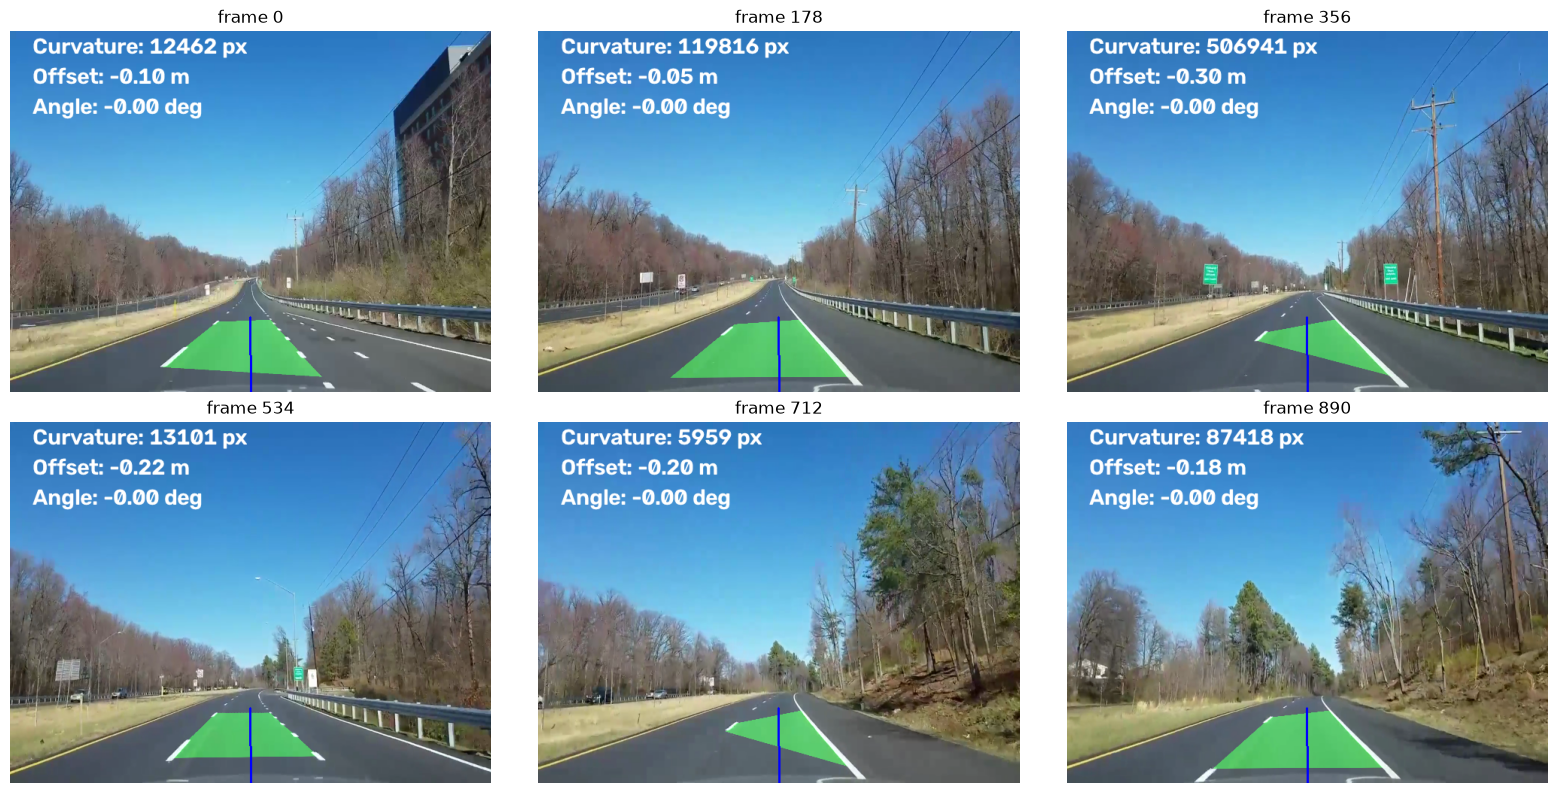

In [27]:
process = make_pipeline()

cap = cv2.VideoCapture(VIDEO)
total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
wanted = set(np.linspace(0, total - 1, 6, dtype=int))

samples, idx = [], 0
while True:
    ok, raw = cap.read()
    if not ok:
        break
    out = process(raw)          # run every frame: tracking is stateful
    if idx in wanted:
        samples.append((idx, out))
    idx += 1
cap.release()

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, (i, img) in zip(axes.ravel(), samples):
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(f"frame {i}")
    ax.axis("off")
plt.tight_layout()
plt.show()

### Export

Writes the annotated clip to `lane_output.mp4`.

In [28]:
process = make_pipeline()

cap = cv2.VideoCapture(VIDEO)
fps = cap.get(cv2.CAP_PROP_FPS) or 30
writer = cv2.VideoWriter("lane_output.mp4", cv2.VideoWriter_fourcc(*"mp4v"), fps, (FRAME_W, FRAME_H))

while True:
    ok, raw = cap.read()
    if not ok:
        break
    writer.write(process(raw))

cap.release()
writer.release()
print("wrote lane_output.mp4")

wrote lane_output.mp4
